#Import libraries

In [7]:
!pip install spacy scikit-learn imbalanced-learn surprise streamlit
!pip install sentence-transformers wordcloud plotly
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 127.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [8]:
!pip install -q "numpy==1.26.4" scikit-surprise matplotlib --force-reinstall

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 

In [9]:
import pandas as pd
import numpy as np
import re
import json
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud

# NLP
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder

# ML - Classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)

# ML - Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Recommender
from surprise import Dataset, Reader, SVD, KNNBasic, NMF
from surprise.model_selection import cross_validate
import surprise

# Sentence embeddings for RAG
from sklearn.metrics.pairwise import cosine_similarity

print("All libraries imported successfully")

All libraries imported successfully


#Load dataset

In [10]:
from google.colab import drive
drive.mount('/content/drive')

df_raw = pd.read_csv('/content/drive/MyDrive/RateMyProfessorDataset/rmp_final_dataset.csv', low_memory=False)

print("Raw shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nFirst record:")
df_raw.head(2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw shape: (4164, 39)

Columns: ['professor_name', 'school_name', 'department_name', 'state_name', 'star_rating', 'diff_index', 'tag_professor', 'post_date', 'student_star', 'student_difficult', 'attence', 'for_credits', 'would_take_agains', 'grades', 'comments', 'word_comment', 'gives_good_feedback', 'caring', 'respected', 'participation_matters', 'clear_grading_criteria', 'skip_class', 'amazing_lectures', 'inspirational', 'tough_grader', 'hilarious', 'get_ready_to_read', 'lots_of_homework', 'accessible_outside_class', 'lecture_heavy', 'extra_credit', 'graded_by_few_things', 'group_projects', 'test_heavy', 'so_many_papers', 'beware_of_pop_quizzes', 'IsCourseOnline', 'dept_category', 'sentiment']

First record:


,professor_name,school_name,department_name,state_name,star_rating,diff_index,tag_professor,post_date,student_star,student_difficult,...,lecture_heavy,extra_credit,graded_by_few_things,group_projects,test_heavy,so_many_papers,beware_of_pop_quizzes,IsCourseOnline,dept_category,sentiment
0,Sheng Zhang,Wayne State University,Mathematics department,MI,3.0,2.4,Clear grading criteria (4) Tough Grader (4) ...,04/09/2007,2.5,1.0,...,0,0,0,0,0,0,1,0,Mathematics,negative
1,Laura Orella,De Anza College,English department,CA,2.2,3.1,Tough Grader (2) LOTS OF HOMEWORK (1) GRADED...,04/12/2005,1.5,5.0,...,0,0,1,1,0,0,0,0,English,negative


#Data Cleaning

In [11]:
df = df_raw.copy()

# ── 2.1 Select relevant columns ─────────────────────────────────
keep_cols = [
    'professor_name', 'school_name', 'department_name', 'state_name',
    'star_rating', 'diff_index', 'would_take_agains', 'post_date',
    'student_star', 'student_difficult', 'grades', 'tag_professor',
    'gives_good_feedback', 'caring', 'respected', 'participation_matters',
    'clear_grading_criteria', 'skip_class', 'amazing_lectures',
    'inspirational', 'tough_grader', 'get_ready_to_read', 'lots_of_homework',
    'accessible_outside_class', 'lecture_heavy', 'extra_credit',
    'graded_by_few_things', 'group_projects', 'test_heavy',
    'so_many_papers', 'beware_of_pop_quizzes', 'IsCourseOnline',
    'comments', 'sentiment', 'dept_category'
]
df = df[[c for c in keep_cols if c in df.columns]].copy()

# ── 2.2 Drop nulls in critical columns ──────────────────────────
df = df.dropna(subset=['comments', 'sentiment']).copy()

# ── 2.3 Remove very short comments (< 10 words) ─────────────────
df['word_count'] = df['comments'].astype(str).apply(lambda x: len(x.split()))
df = df[df['word_count'] >= 10].copy()

# ── 2.4 Remove duplicate comments ───────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['comments']).copy()
print(f"Removed {before - len(df)} duplicate comments")

# ── 2.5 Clean binary tag columns - fill NaN with 0 ──────────────
tag_cols = [
    'gives_good_feedback', 'caring', 'respected', 'participation_matters',
    'clear_grading_criteria', 'skip_class', 'amazing_lectures', 'inspirational',
    'tough_grader', 'get_ready_to_read', 'lots_of_homework',
    'accessible_outside_class', 'lecture_heavy', 'extra_credit',
    'graded_by_few_things', 'group_projects', 'test_heavy',
    'so_many_papers', 'beware_of_pop_quizzes'
]
for col in tag_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# ── 2.6 Clean numeric columns ────────────────────────────────────
df['star_rating']       = pd.to_numeric(df['star_rating'], errors='coerce')
df['diff_index']        = pd.to_numeric(df['diff_index'], errors='coerce')
df['student_star']      = pd.to_numeric(df['student_star'], errors='coerce')
df['student_difficult'] = pd.to_numeric(df['student_difficult'], errors='coerce')

# ── 2.7 Encode would_take_agains ────────────────────────────────
df['would_take_agains'] = df['would_take_agains'].map(
    {'Yes': 1, 'No': 0}
).fillna(0).astype(int)

# ── 2.8 Encode grades ordinally ─────────────────────────────────
grade_map = {
    'A+': 4.3, 'A': 4.0, 'A-': 3.7,
    'B+': 3.3, 'B': 3.0, 'B-': 2.7,
    'C+': 2.3, 'C': 2.0, 'C-': 1.7,
    'D': 1.0, 'F': 0.0
}
df['grade_numeric'] = df['grades'].map(grade_map).fillna(
    df['grades'].map(grade_map).median()
)

# ── 2.9 Reset index ──────────────────────────────────────────────
df = df.reset_index(drop=True)

print("\n Data cleaning complete!")
print("Final shape:", df.shape)
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())
print("\nDepartment distribution:")
print(df['dept_category'].value_counts())

Removed 4 duplicate comments

 Data cleaning complete!
Final shape: (4160, 37)

Sentiment distribution:
sentiment
positive    2485
negative    1153
neutral      522
Name: count, dtype: int64

Department distribution:
dept_category
English        1249
Mathematics     972
Psychology      722
History         610
Biology         607
Name: count, dtype: int64


#Text Preprocessing and Feature Engineering

In [12]:
nlp = spacy.load("en_core_web_sm")

# ── 3.1 Basic text cleaning ─────────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)          # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", " ", text)      # keep only letters
    text = re.sub(r"\s+", " ", text).strip()       # normalize whitespace
    return text

df['clean_comments'] = df['comments'].apply(clean_text)

# ── 3.2 NER: Extract named entities using SpaCy ─────────────────
def extract_entities(text):
    """Extract named entities: PERSON, ORG, GPE etc."""
    doc = nlp(str(text)[:500])  # limit to 500 chars for speed
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

def extract_person_entities(text):
    doc = nlp(str(text)[:500])
    people = [ent.text for ent in doc.ents if ent.label_ == 'PERSON']
    return people

print("Running SpaCy NER... (this takes ~2 minutes)")
df['entities']       = df['comments'].apply(extract_entities)
df['person_mentions'] = df['comments'].apply(extract_person_entities)
df['has_person_mention'] = df['person_mentions'].apply(lambda x: 1 if x else 0)
print("NER complete!")

# ── 3.3 Aspect Extraction using SpaCy dependency parsing ────────
ASPECT_KEYWORDS = {
    'exams':     ['exam', 'test', 'quiz', 'midterm', 'final', 'assessment'],
    'grading':   ['grade', 'grading', 'rubric', 'score', 'mark', 'credit', 'gpa'],
    'workload':  ['homework', 'assignment', 'work', 'reading', 'load', 'paper', 'project'],
    'lectures':  ['lecture', 'class', 'explain', 'teaching', 'slide', 'lesson', 'material'],
    'professor': ['professor', 'teacher', 'prof', 'instructor', 'dr', 'she', 'he'],
    'attendance':['attend', 'attendance', 'mandatory', 'skip', 'absent', 'presence']
}

def extract_aspects(text):
    doc = nlp(str(text).lower()[:500])
    found = []
    for token in doc:
        for aspect, keywords in ASPECT_KEYWORDS.items():
            if token.lemma_ in keywords or token.text in keywords:
                found.append(aspect)
    unique = list(set(found))
    return unique if unique else ['general']

def extract_aspect_opinion_pairs(text):
    """Extract (aspect, opinion_word) pairs using dependency parsing"""
    doc = nlp(str(text).lower()[:500])
    pairs = []
    for token in doc:
        for aspect, keywords in ASPECT_KEYWORDS.items():
            if token.lemma_ in keywords:
                # Look for adjective children (opinion words)
                for child in token.children:
                    if child.pos_ == 'ADJ':
                        pairs.append((aspect, child.text))
                # Look for adjective head
                if token.head.pos_ == 'ADJ':
                    pairs.append((aspect, token.head.text))
    return pairs

print("Running aspect extraction...")
df['aspects']              = df['clean_comments'].apply(extract_aspects)
df['aspect_opinion_pairs'] = df['clean_comments'].apply(extract_aspect_opinion_pairs)
df['primary_aspect']       = df['aspects'].apply(lambda x: x[0] if x else 'general')
df['num_aspects']          = df['aspects'].apply(len)
print("Aspect extraction complete!")

# ── 3.4 Extra text features ─────────────────────────────────────
df['comment_length']      = df['clean_comments'].apply(lambda x: len(x.split()))
df['avg_word_length']     = df['clean_comments'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)
df['exclamation_count']   = df['comments'].apply(lambda x: str(x).count('!'))
df['question_count']      = df['comments'].apply(lambda x: str(x).count('?'))
df['uppercase_ratio']     = df['comments'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)

# Positive/negative lexicon word counts
POSITIVE_WORDS = {'great', 'excellent', 'amazing', 'wonderful', 'best', 'good',
                  'helpful', 'clear', 'fantastic', 'love', 'awesome', 'brilliant'}
NEGATIVE_WORDS = {'bad', 'terrible', 'awful', 'worst', 'boring', 'hard', 'difficult',
                  'confusing', 'unfair', 'horrible', 'waste', 'useless', 'poor'}

def count_pos_words(text):
    words = set(str(text).lower().split())
    return len(words & POSITIVE_WORDS)

def count_neg_words(text):
    words = set(str(text).lower().split())
    return len(words & NEGATIVE_WORDS)

df['positive_word_count'] = df['clean_comments'].apply(count_pos_words)
df['negative_word_count'] = df['clean_comments'].apply(count_neg_words)
df['sentiment_word_ratio'] = (df['positive_word_count'] - df['negative_word_count']) / \
                              (df['comment_length'] + 1)

print("\nFeature engineering complete!")
print("New feature columns added:")
new_features = ['comment_length', 'avg_word_length', 'exclamation_count',
                'question_count', 'uppercase_ratio', 'positive_word_count',
                'negative_word_count', 'sentiment_word_ratio',
                'has_person_mention', 'num_aspects', 'primary_aspect']
print(new_features)
print("\nSample aspects extracted:")
print(df[['comments', 'aspects', 'primary_aspect', 'aspect_opinion_pairs']].head(5))

Running SpaCy NER... (this takes ~2 minutes)
NER complete!
Running aspect extraction...
Aspect extraction complete!

Feature engineering complete!
New feature columns added:
['comment_length', 'avg_word_length', 'exclamation_count', 'question_count', 'uppercase_ratio', 'positive_word_count', 'negative_word_count', 'sentiment_word_ratio', 'has_person_mention', 'num_aspects', 'primary_aspect']

Sample aspects extracted:
                                            comments  \
0  He seems to know his stuff. However, he wastes...   
1  This is an online class in which she requires ...   
2  Good luck if you have this professor - he is k...   
3  she\'s a sweet woman, but man...her lectures w...   
4  if you\'re interested in plants, agriculture, ...   

                                    aspects primary_aspect  \
0    [lectures, professor, workload, exams]       lectures   
1  [grading, professor, workload, lectures]        grading   
2              [professor, exams, lectures]      profes

#Visualizations - Data Exploration

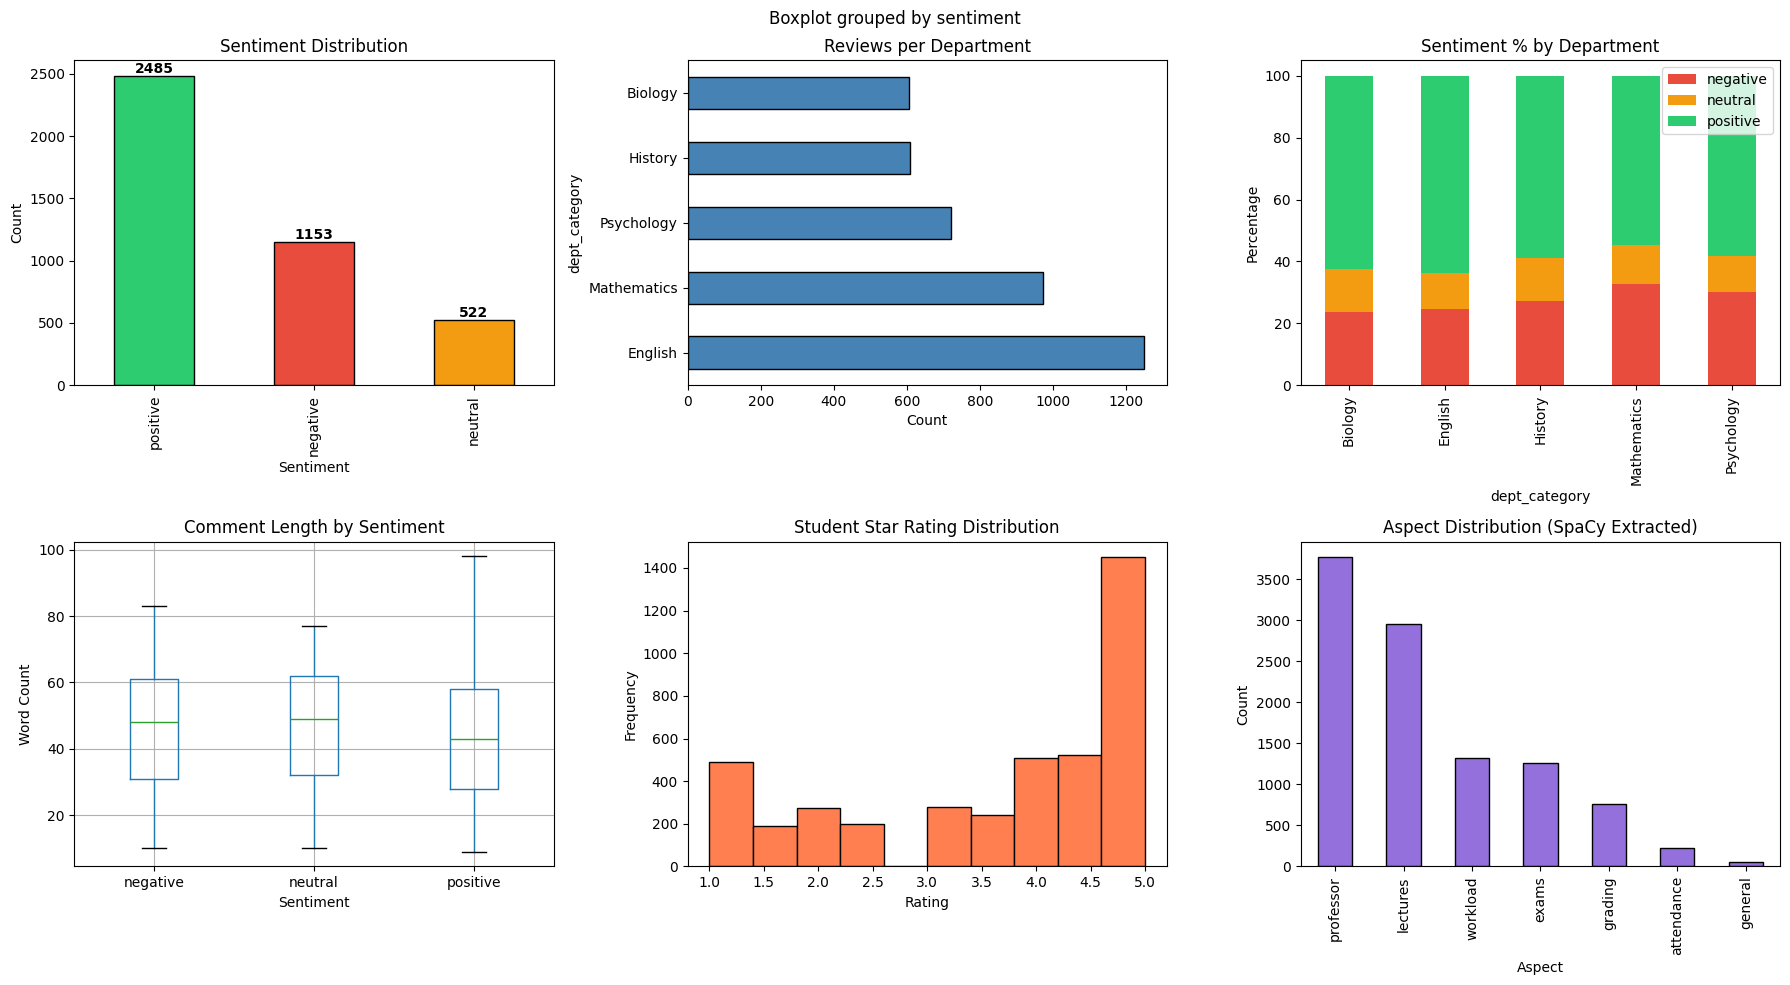

Saved: 01_data_overview.png


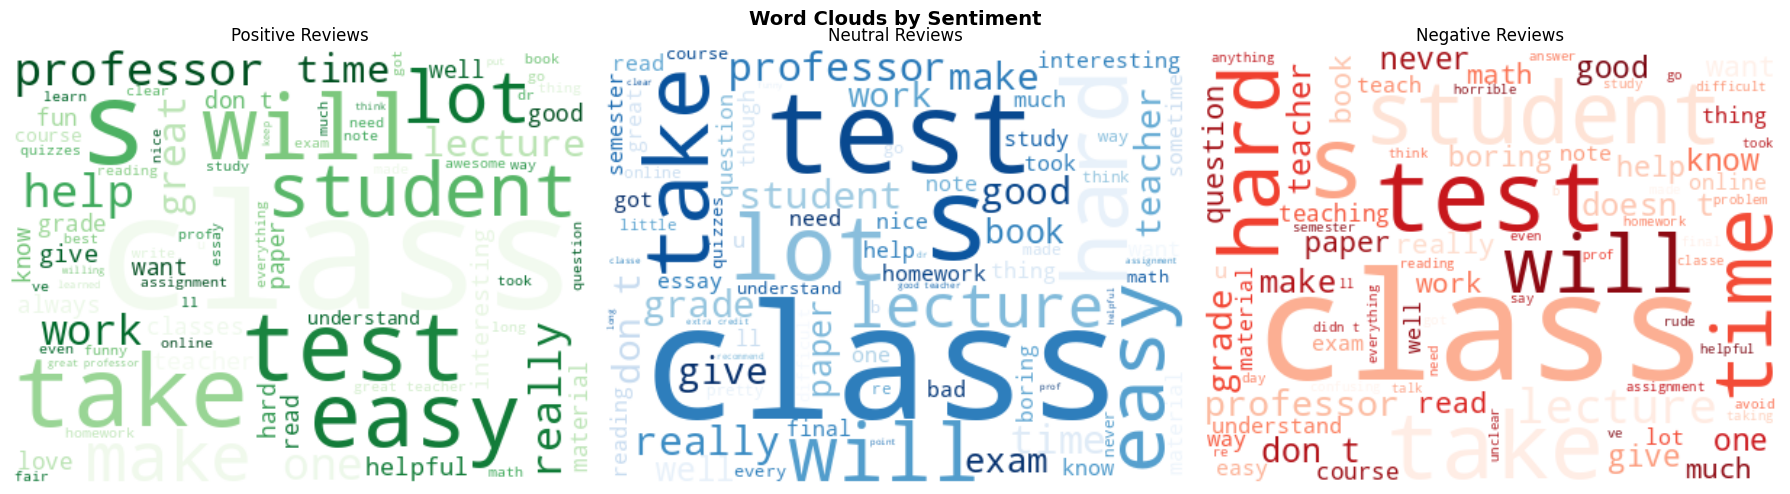

Saved: 02_wordclouds.png


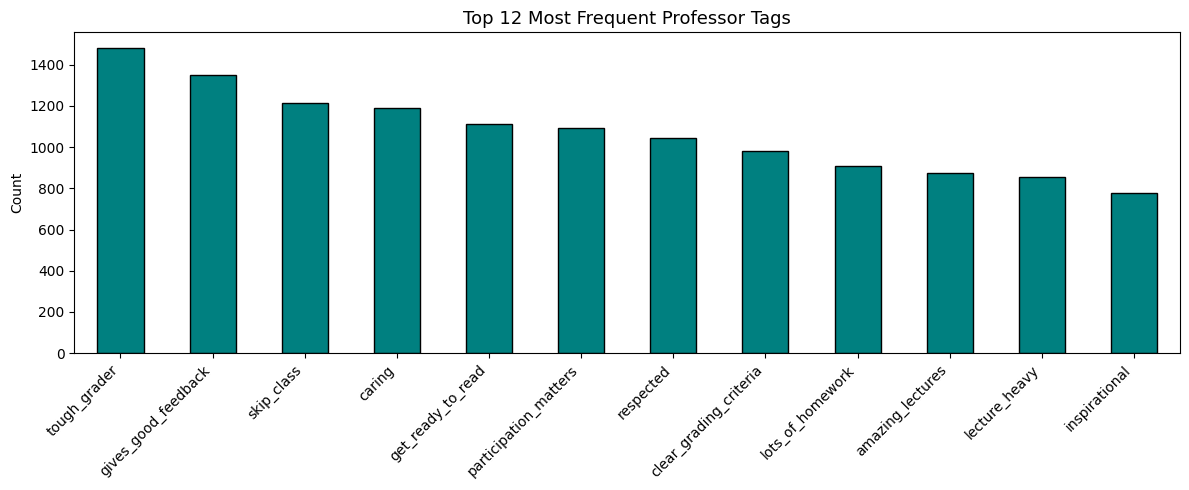

Saved: 03_tag_frequency.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold')

# 4.1 Sentiment distribution
df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c','#f39c12'], edgecolor='black'
)
axes[0,0].set_title('Sentiment Distribution')
axes[0,0].set_xlabel('Sentiment')
axes[0,0].set_ylabel('Count')
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontweight='bold')

# 4.2 Department distribution
df['dept_category'].value_counts().plot(
    kind='barh', ax=axes[0,1], color='steelblue', edgecolor='black'
)
axes[0,1].set_title('Reviews per Department')
axes[0,1].set_xlabel('Count')

# 4.3 Sentiment per department (heatmap style)
sentiment_dept = pd.crosstab(df['dept_category'], df['sentiment'], normalize='index') * 100
sentiment_dept.plot(kind='bar', ax=axes[0,2], stacked=True,
                    color=['#e74c3c','#f39c12','#2ecc71'])
axes[0,2].set_title('Sentiment % by Department')
axes[0,2].set_ylabel('Percentage')
axes[0,2].legend(loc='upper right')

# 4.4 Comment length distribution
df.boxplot(column='comment_length', by='sentiment', ax=axes[1,0])
axes[1,0].set_title('Comment Length by Sentiment')
axes[1,0].set_xlabel('Sentiment')
axes[1,0].set_ylabel('Word Count')

# 4.5 Star rating distribution
df['student_star'].dropna().plot(
    kind='hist', bins=10, ax=axes[1,1], color='coral', edgecolor='black'
)
axes[1,1].set_title('Student Star Rating Distribution')
axes[1,1].set_xlabel('Rating')

# 4.6 Top aspect distribution
aspect_flat = [a for aspects in df['aspects'] for a in aspects]
aspect_series = pd.Series(aspect_flat).value_counts()
aspect_series.plot(kind='bar', ax=axes[1,2], color='mediumpurple', edgecolor='black')
axes[1,2].set_title('Aspect Distribution (SpaCy Extracted)')
axes[1,2].set_xlabel('Aspect')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('/content/01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_data_overview.png")

# 4.7 Word clouds per sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Clouds by Sentiment', fontsize=14, fontweight='bold')

colors = {'positive': 'Greens', 'neutral': 'Blues', 'negative': 'Reds'}
for ax, sentiment in zip(axes, ['positive', 'neutral', 'negative']):
    text = ' '.join(df[df['sentiment'] == sentiment]['clean_comments'])
    wc = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap=colors[sentiment],
        max_words=80
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Reviews', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/02_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_wordclouds.png")

# 4.8 Top 10 Tag frequencies
tag_sums = df[tag_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
tag_sums.head(12).plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 12 Most Frequent Professor Tags', fontsize=13)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/03_tag_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_tag_frequency.png")

#TF-IDF Vectorization and Train-Test Split

In [14]:
# ── 5.1 TF-IDF ──────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # apply log normalization
    min_df=3               # ignore very rare terms
)

X_tfidf = tfidf.fit_transform(df['clean_comments'])
print("TF-IDF matrix shape:", X_tfidf.shape)

# ── 5.2 Extra numeric features to stack with TF-IDF ─────────────
from scipy.sparse import hstack, csr_matrix

numeric_features = df[[
    'comment_length', 'avg_word_length', 'exclamation_count',
    'question_count', 'uppercase_ratio', 'positive_word_count',
    'negative_word_count', 'sentiment_word_ratio',
    'has_person_mention', 'num_aspects',
    'diff_index', 'student_difficult', 'would_take_agains'
]].fillna(0).values

X_combined = hstack([X_tfidf, csr_matrix(numeric_features)])
print("Combined feature matrix shape:", X_combined.shape)

# ── 5.3 Labels ──────────────────────────────────────────────────
y = df['sentiment']
print("\nClass distribution:")
print(y.value_counts())

# ── 5.4 Train/test split ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# ── 5.5 SMOTE to fix class imbalance ────────────────────────────
print("\nApplying SMOTE...")
print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())
print("SMOTE applied - classes are now balanced!")

TF-IDF matrix shape: (4160, 5000)
Combined feature matrix shape: (4160, 5013)

Class distribution:
sentiment
positive    2485
negative    1153
neutral      522
Name: count, dtype: int64

Train: 3328 | Test: 832

Applying SMOTE...
Before SMOTE: {'positive': 1988, 'negative': 922, 'neutral': 418}
After SMOTE: {'positive': 1988, 'neutral': 1988, 'negative': 1988}
SMOTE applied - classes are now balanced!


#Classification - 5 Models


Training Logistic Regression...
  Accuracy:    0.7692
  F1 Macro:    0.6805
  F1 Weighted: 0.7778

Training Linear SVM...
  Accuracy:    0.7740
  F1 Macro:    0.6648
  F1 Weighted: 0.7747

Training Naive Bayes...
  Accuracy:    0.7320
  F1 Macro:    0.6211
  F1 Weighted: 0.7355

Training Random Forest...
  Accuracy:    0.7656
  F1 Macro:    0.5745
  F1 Weighted: 0.7292

Training Gradient Boosting...
  Accuracy:    0.7584
  F1 Macro:    0.6041
  F1 Weighted: 0.7408


=== FULL CLASSIFICATION REPORTS ===

  Logistic Regression
              precision    recall  f1-score   support

    negative       0.76      0.81      0.78       231
     neutral       0.36      0.46      0.41       104
    positive       0.90      0.81      0.85       497

    accuracy                           0.77       832
   macro avg       0.67      0.70      0.68       832
weighted avg       0.79      0.77      0.78       832


  Linear SVM
              precision    recall  f1-score   support

    negative       

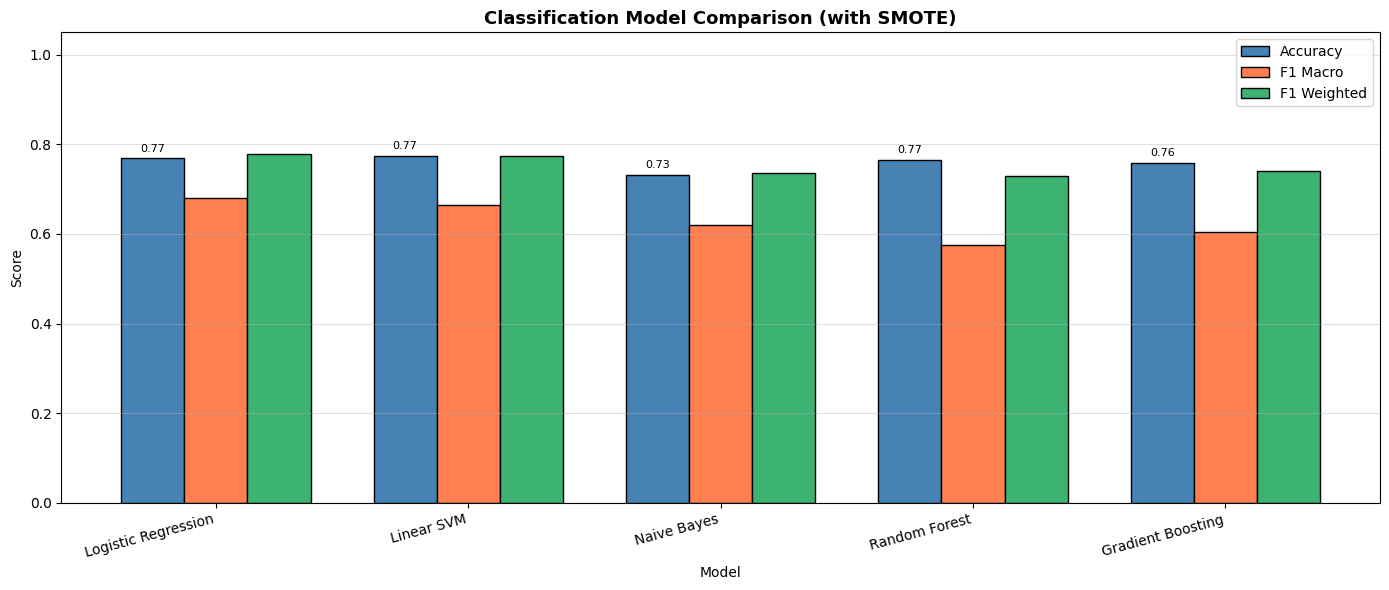

Saved: 04_model_comparison.png


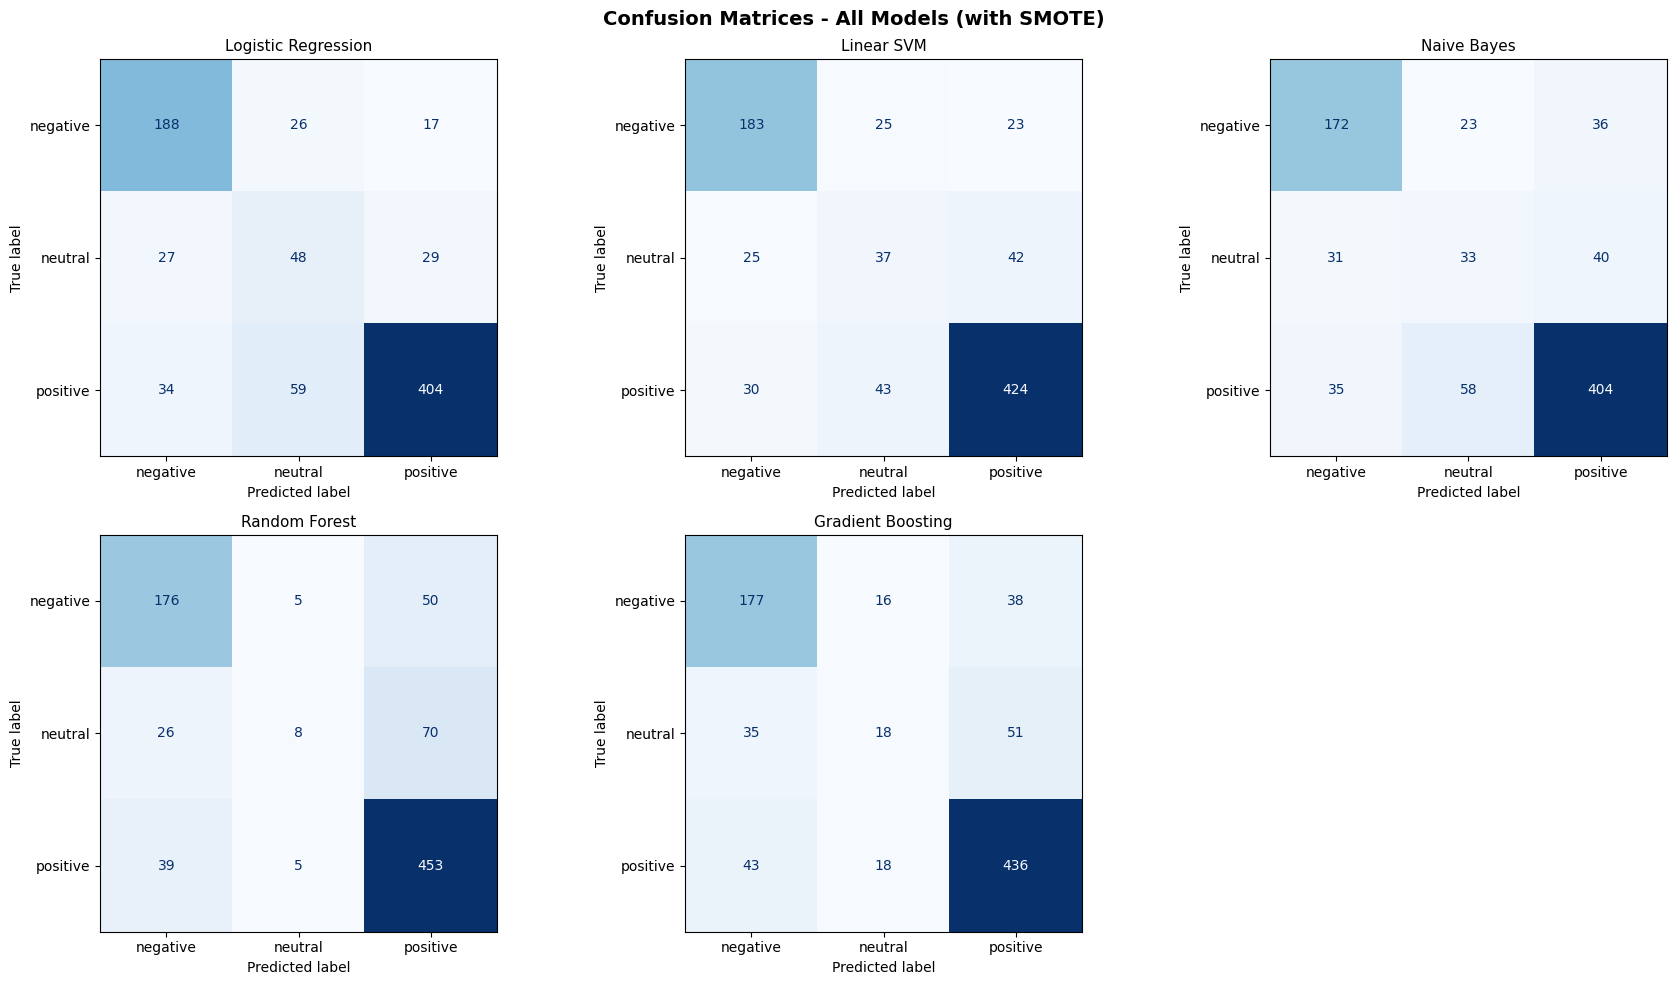

Saved: 05_confusion_matrices.png

Best model: Logistic Regression


In [15]:
# ── 6.1 Define models ───────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, C=1.0, random_state=42),
    'Linear SVM':          LinearSVC(max_iter=2000, C=1.0, random_state=42),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Note: Naive Bayes needs non-negative features — use tfidf only (no combined)
X_train_tfidf = X_tfidf[:X_train.shape[0]]  # approximate — use proper split below

# Proper split for NB (TF-IDF only, no negative values)
X_tfidf_only = tfidf.transform(df['clean_comments'])
X_tr_nb, X_te_nb, y_tr_nb, y_te_nb = train_test_split(
    X_tfidf_only, y, test_size=0.2, random_state=42, stratify=y
)
X_tr_nb_sm, y_tr_nb_sm = smote.fit_resample(X_tr_nb, y_tr_nb)

# ── 6.2 Train and evaluate all models ───────────────────────────
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == 'Naive Bayes':
        model.fit(X_tr_nb_sm, y_tr_nb_sm)
        y_pred = model.predict(X_te_nb)
        y_true = y_te_nb
    else:
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test)
        y_true = y_test

    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_true':    y_true,
        'accuracy':  acc,
        'f1_macro':  f1_mac,
        'f1_weighted': f1_wt
    }

    print(f"  Accuracy:    {acc:.4f}")
    print(f"  F1 Macro:    {f1_mac:.4f}")
    print(f"  F1 Weighted: {f1_wt:.4f}")

print("\n\n=== FULL CLASSIFICATION REPORTS ===")
for name, res in results.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(res['y_true'], res['y_pred'], zero_division=0))


# ── 6.3 Model Comparison Visualization ──────────────────────────
model_names  = list(results.keys())
accuracies   = [results[n]['accuracy']    for n in model_names]
f1_macros    = [results[n]['f1_macro']    for n in model_names]
f1_weighteds = [results[n]['f1_weighted'] for n in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, accuracies,   width, label='Accuracy',    color='steelblue',  edgecolor='black')
bars2 = ax.bar(x,          f1_macros,   width, label='F1 Macro',    color='coral',      edgecolor='black')
bars3 = ax.bar(x + width,  f1_weighteds,width, label='F1 Weighted', color='mediumseagreen', edgecolor='black')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison (with SMOTE)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_model_comparison.png")

# ── 6.4 Confusion Matrices - All Models ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrices - All Models (with SMOTE)', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['negative', 'neutral', 'positive']
    )
    disp.plot(ax=axes_flat[i], colorbar=False, cmap='Blues')
    axes_flat[i].set_title(name, fontsize=11)

# Hide unused subplot
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('/content/05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_confusion_matrices.png")

# ── 6.5 Cross-validation for best model ─────────────────────────
best_model_name = max(results, key=lambda n: results[n]['f1_macro'])
best_model      = results[best_model_name]['model']
print(f"\nBest model: {best_model_name}")

In [16]:
# Cross-val on LR (most stable)
lr_model = results['Logistic Regression']['model']
cv_scores = cross_val_score(
    LogisticRegression(max_iter=2000, C=1.0, random_state=42),
    X_tfidf_only, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro'
)
print(f"\nLogistic Regression 5-Fold CV F1 Macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ── 6.6 Save best model ─────────────────────────────────────────
joblib.dump(results['Logistic Regression']['model'], '/content/best_model_lr.joblib')
joblib.dump(tfidf, '/content/tfidf_vectorizer.joblib')
print("Model and vectorizer saved!")


Logistic Regression 5-Fold CV F1 Macro: 0.5349 ± 0.0105
Model and vectorizer saved!


#Error Analysis

Total misclassified: 192 / 832 (23.1%)

Error type breakdown:
error_type
positive → neutral     59
positive → negative    34
neutral → positive     29
neutral → negative     27
negative → neutral     26
negative → positive    17
Name: count, dtype: int64


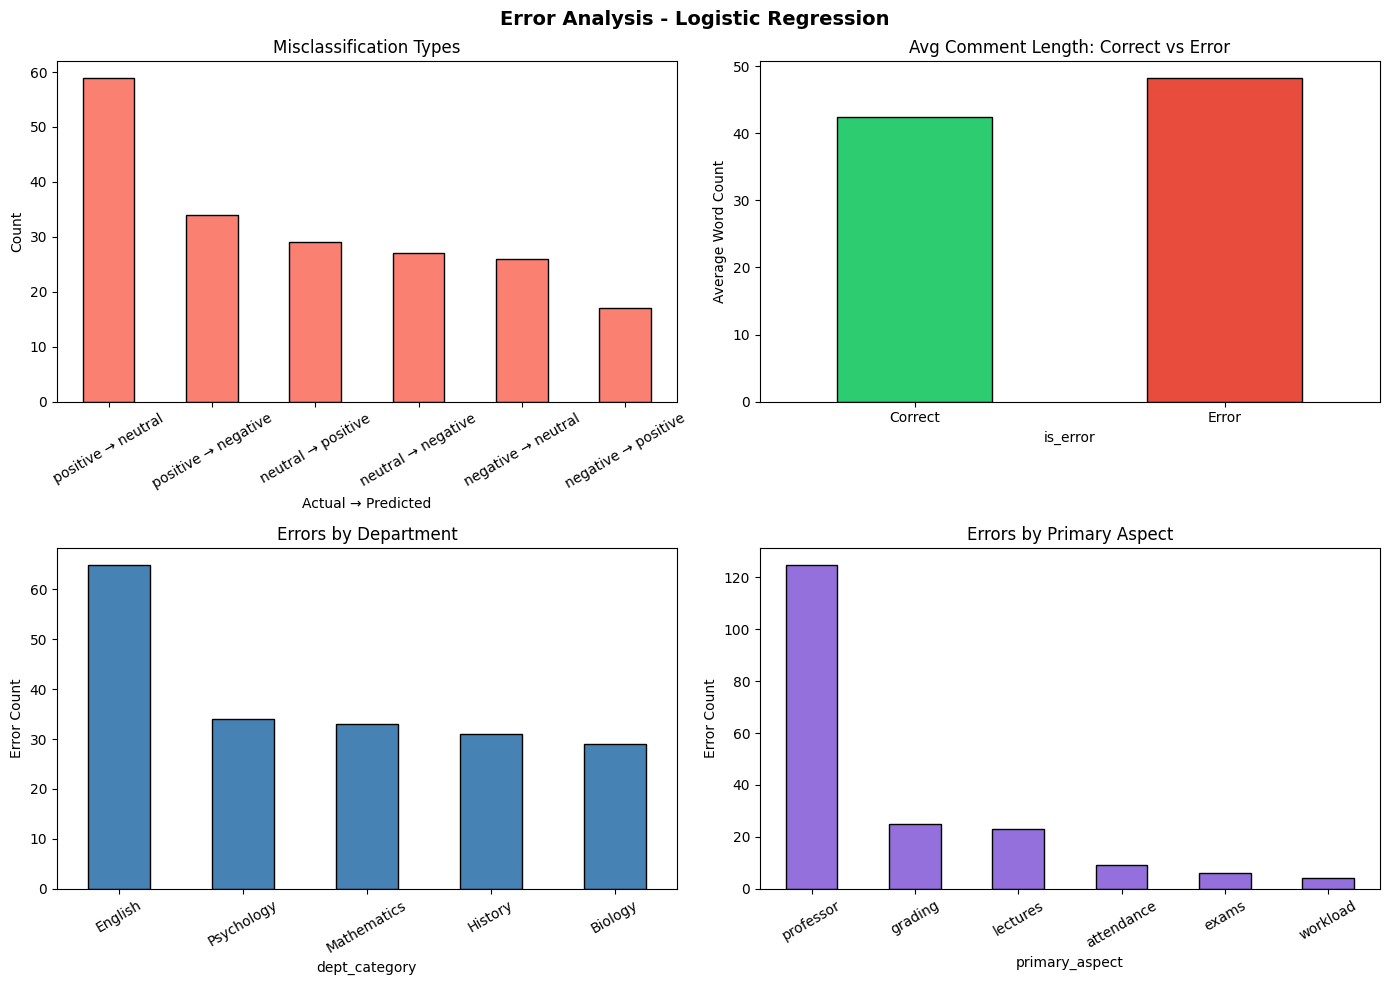

Saved: 06_error_analysis.png

=== SAMPLE MISCLASSIFICATIONS ===

── positive → neutral ──
  Comment: She knows the history very well. Overall shes an alright person but at times she comes off as tough, rude and strict. Bu...
  Actual: positive | Predicted: neutral
  Comment: Most interesting class with up to date topics. All work was clear, lots of films and group projects . Never boring!...
  Actual: positive | Predicted: neutral

── positive → negative ──
  Comment: Very very smart. Basically knows everything about history and can answer any question. Doesn\'t give quizzes and assigne...
  Actual: positive | Predicted: negative
  Comment: Eleanor intimidated the hell out of me when I first had her. She\'s smart, can defend her views, and expects the same ou...
  Actual: positive | Predicted: negative

── neutral → positive ──
  Comment: dr wilson is interesting.. he talks to himself a lot and his lectures are boring but if you show up its super easy. you ...
  Actual: neutral | Predi

In [17]:
# Use Logistic Regression predictions for error analysis
lr_pred   = results['Logistic Regression']['y_pred']
lr_true   = results['Logistic Regression']['y_true']

# Build error dataframe
test_idx = y_test.index  # original indices
error_df = pd.DataFrame({
    'comment':            df.loc[test_idx, 'comments'].values,
    'clean_comment':      df.loc[test_idx, 'clean_comments'].values,
    'actual':             lr_true.values,
    'predicted':          lr_pred,
    'dept_category':      df.loc[test_idx, 'dept_category'].values,
    'comment_length':     df.loc[test_idx, 'comment_length'].values,
    'positive_word_count':df.loc[test_idx, 'positive_word_count'].values,
    'negative_word_count':df.loc[test_idx, 'negative_word_count'].values,
    'primary_aspect':     df.loc[test_idx, 'primary_aspect'].values,
})
error_df['is_error']   = error_df['actual'] != error_df['predicted']
error_df['error_type'] = error_df.apply(
    lambda r: f"{r['actual']} → {r['predicted']}" if r['is_error'] else 'correct', axis=1
)

errors = error_df[error_df['is_error']].copy()
print(f"Total misclassified: {len(errors)} / {len(error_df)} ({len(errors)/len(error_df)*100:.1f}%)")
print("\nError type breakdown:")
print(errors['error_type'].value_counts())

# ── 7.1 Error Analysis Visualizations ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Error Analysis - Logistic Regression', fontsize=14, fontweight='bold')

# Error type breakdown
errors['error_type'].value_counts().plot(
    kind='bar', ax=axes[0,0], color='salmon', edgecolor='black'
)
axes[0,0].set_title('Misclassification Types')
axes[0,0].set_xlabel('Actual → Predicted')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=30)

# Comment length: errors vs correct
error_df.groupby('is_error')['comment_length'].mean().plot(
    kind='bar', ax=axes[0,1], color=['#2ecc71', '#e74c3c'], edgecolor='black'
)
axes[0,1].set_title('Avg Comment Length: Correct vs Error')
axes[0,1].set_xticklabels(['Correct', 'Error'], rotation=0)
axes[0,1].set_ylabel('Average Word Count')

# Errors by department
errors['dept_category'].value_counts().plot(
    kind='bar', ax=axes[1,0], color='steelblue', edgecolor='black'
)
axes[1,0].set_title('Errors by Department')
axes[1,0].set_ylabel('Error Count')
axes[1,0].tick_params(axis='x', rotation=30)

# Errors by aspect
errors['primary_aspect'].value_counts().head(8).plot(
    kind='bar', ax=axes[1,1], color='mediumpurple', edgecolor='black'
)
axes[1,1].set_title('Errors by Primary Aspect')
axes[1,1].set_ylabel('Error Count')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/06_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_error_analysis.png")

# ── 7.2 Show actual misclassified examples ───────────────────────
print("\n=== SAMPLE MISCLASSIFICATIONS ===")
for error_type in errors['error_type'].value_counts().head(4).index:
    subset = errors[errors['error_type'] == error_type].head(2)
    print(f"\n── {error_type} ──")
    for _, row in subset.iterrows():
        print(f"  Comment: {row['comment'][:120]}...")
        print(f"  Actual: {row['actual']} | Predicted: {row['predicted']}")

errors.to_csv('/content/error_analysis_full.csv', index=False)
print("\nSaved: error_analysis_full.csv")

#Clustering

Cluster TF-IDF shape: (4160, 3000)
SVD explained variance: 25.50%

Running Elbow + Silhouette analysis...
  k=2: inertia=1019, silhouette=0.0356
  k=3: inertia=1005, silhouette=0.0220
  k=4: inertia=992, silhouette=0.0285
  k=5: inertia=985, silhouette=0.0151
  k=6: inertia=975, silhouette=0.0213
  k=7: inertia=964, silhouette=0.0221
  k=8: inertia=954, silhouette=0.0204
  k=9: inertia=946, silhouette=0.0180
  k=10: inertia=939, silhouette=0.0344


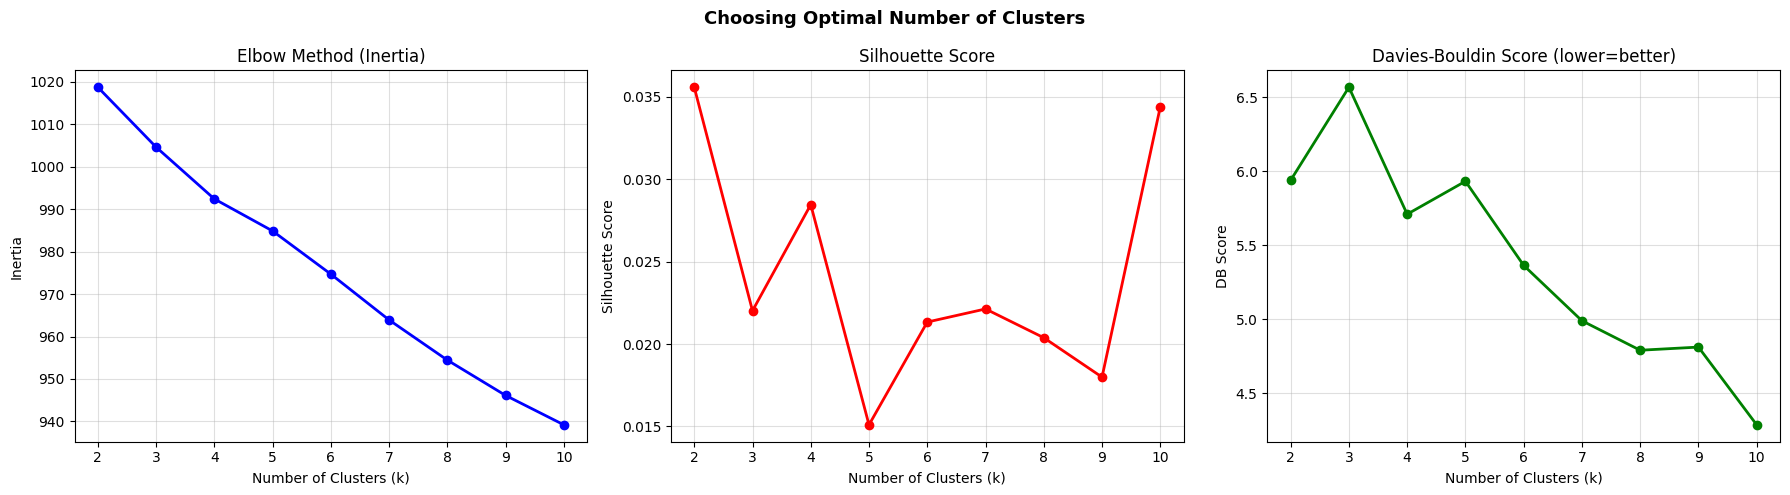

Saved: 07_cluster_selection.png


In [18]:
# ── 8.1 TF-IDF for clustering (separate vectorizer) ─────────────
tfidf_cluster = TfidfVectorizer(
    stop_words='english',
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3
)
X_cluster = tfidf_cluster.fit_transform(df['clean_comments'])
print("Cluster TF-IDF shape:", X_cluster.shape)

# ── 8.2 Dimensionality reduction for clustering + visualization ──
svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_cluster)
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum():.2%}")

# ── 8.3 Elbow Method + Silhouette to choose k ───────────────────
print("\nRunning Elbow + Silhouette analysis...")
inertias   = []
sil_scores = []
db_scores  = []
K_range    = range(2, 11)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_svd)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_svd, labels))
    db_scores.append(davies_bouldin_score(X_svd, labels))
    print(f"  k={k}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Choosing Optimal Number of Clusters', fontsize=13, fontweight='bold')

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.4)

axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.4)

axes[2].plot(K_range, db_scores, 'go-', linewidth=2)
axes[2].set_title('Davies-Bouldin Score (lower=better)')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('DB Score')
axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('/content/07_cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_cluster_selection.png")


KMeans (k=5) Silhouette Score: 0.0151
DBSCAN → Clusters: 1, Noise points: 0
Agglomerative Silhouette Score: 0.0147

=== CLUSTERING ALGORITHM COMPARISON ===
KMeans        Silhouette: 0.0151
Agglomerative Silhouette: 0.0147
DBSCAN        Clusters found: 1, Noise: 0

=== CLUSTER INTERPRETATION ===

Cluster 0 top terms: ability, abnormal, absolute, absent, absolutely loved, accept, academic, advise, adult, adorable, algebra, anatomy

Cluster 1 top terms: ability, absolutely loved, able, absolute, absent, ace, actually learn, advanced, academic, active, accent, actual

Cluster 2 top terms: ability, absolutely, absolutely horrible, absolute, act, absent, able, advanced, accent, alot, american, advise

Cluster 3 top terms: ability, accent, accessible, aced, afraid, add, addition, acts, advantage, actually, answering, activities

Cluster 4 top terms: ability, able, abnormal, ace, active, adds, academic, accept, absolutely loved, adorable, agree, ago

Sentiment % per cluster:
sentiment       n

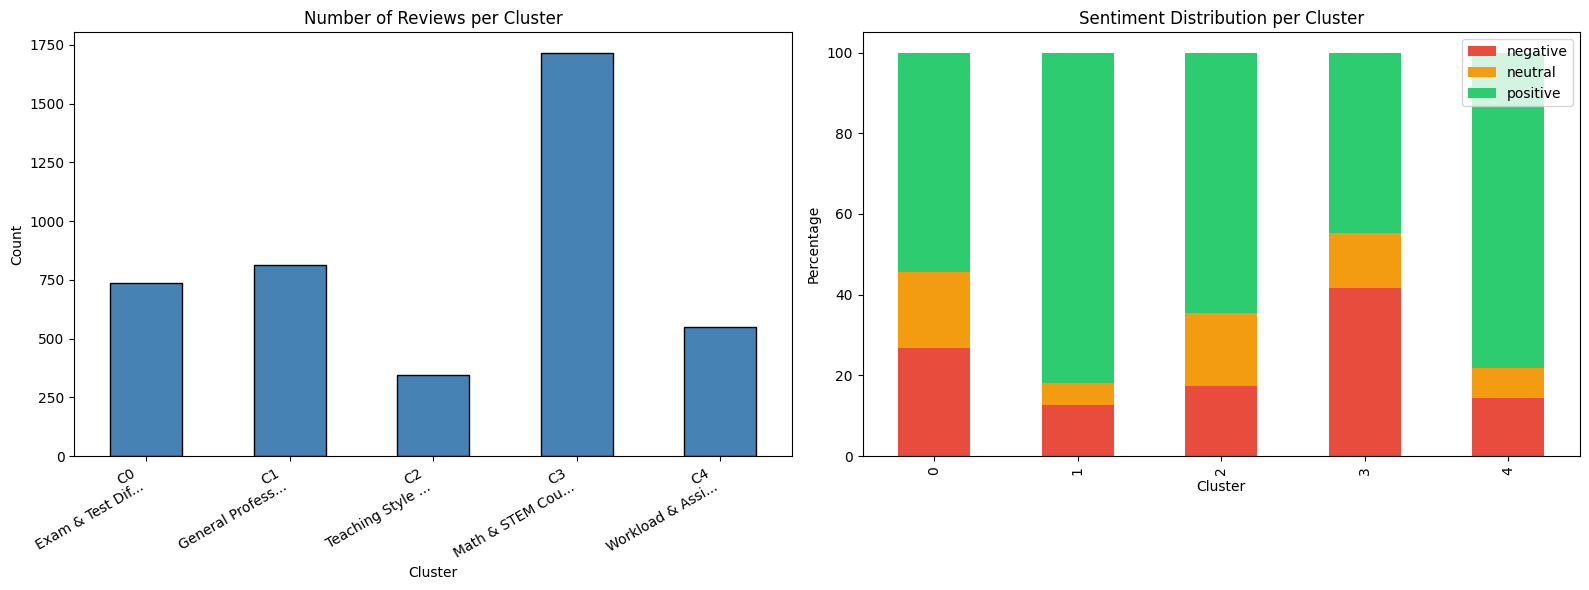

Saved: 08_cluster_analysis.png

Running PCA + t-SNE (takes ~3 minutes)...


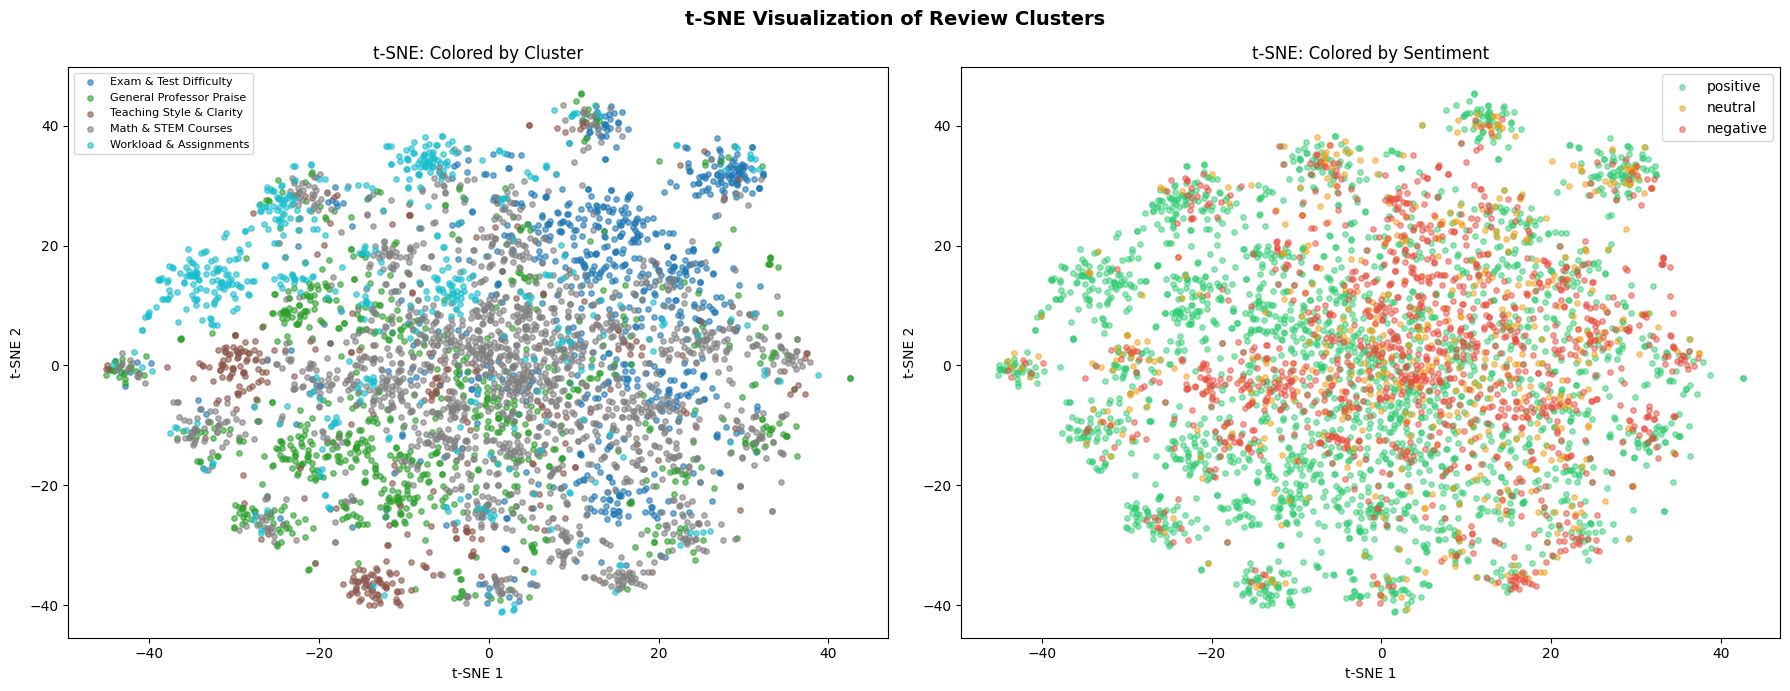

Saved: 09_tsne_clusters.png


In [19]:
# ── 8.4 KMeans with optimal k=5 ─────────────────────────────────
OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_svd)
df['kmeans_cluster'] = kmeans_labels
kmeans_sil = silhouette_score(X_svd, kmeans_labels)
print(f"\nKMeans (k={OPTIMAL_K}) Silhouette Score: {kmeans_sil:.4f}")

# ── 8.5 DBSCAN ──────────────────────────────────────────────────
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_svd)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise       = list(dbscan_labels).count(-1)
df['dbscan_cluster'] = dbscan_labels
print(f"DBSCAN → Clusters: {n_clusters_db}, Noise points: {n_noise}")

# ── 8.6 Agglomerative Clustering ────────────────────────────────
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K)
agg_labels = agg.fit_predict(X_svd)
df['agg_cluster'] = agg_labels
agg_sil = silhouette_score(X_svd, agg_labels)
print(f"Agglomerative Silhouette Score: {agg_sil:.4f}")

# ── 8.7 Clustering comparison ───────────────────────────────────
print("\n=== CLUSTERING ALGORITHM COMPARISON ===")
print(f"KMeans        Silhouette: {kmeans_sil:.4f}")
print(f"Agglomerative Silhouette: {agg_sil:.4f}")
print(f"DBSCAN        Clusters found: {n_clusters_db}, Noise: {n_noise}")

# ── 8.8 Interpret KMeans clusters via top terms ──────────────────
terms = tfidf_cluster.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

cluster_keywords = {}
print("\n=== CLUSTER INTERPRETATION ===")
for i in range(OPTIMAL_K):
    top_terms = [terms[ind] for ind in order_centroids[i, :12]]
    cluster_keywords[i] = top_terms
    print(f"\nCluster {i} top terms: {', '.join(top_terms)}")

# Manual interpretation based on terms
cluster_name_map = {
    0: "Exam & Test Difficulty",
    1: "General Professor Praise",
    2: "Teaching Style & Clarity",
    3: "Math & STEM Courses",
    4: "Workload & Assignments"
}
df['cluster_name'] = df['kmeans_cluster'].map(cluster_name_map)

# ── 8.9 Cluster sentiment breakdown ─────────────────────────────
cluster_sentiment = pd.crosstab(df['kmeans_cluster'], df['sentiment'], normalize='index') * 100
print("\nSentiment % per cluster:")
print(cluster_sentiment.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cluster sizes
df['kmeans_cluster'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Number of Reviews per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(
    [f"C{i}\n{cluster_name_map[i][:15]}..." for i in range(OPTIMAL_K)],
    rotation=30, ha='right'
)

# Cluster sentiment stacked bar
cluster_sentiment.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#e74c3c', '#f39c12', '#2ecc71']
)
axes[1].set_title('Sentiment Distribution per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Percentage')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('/content/08_cluster_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_cluster_analysis.png")

# ── 8.10 PCA + t-SNE Visualization ──────────────────────────────
print("\nRunning PCA + t-SNE (takes ~3 minutes)...")

# PCA first to speed up t-SNE
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_svd)

tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('t-SNE Visualization of Review Clusters', fontsize=14, fontweight='bold')

# By cluster  ← FIXED: use plt.cm instead of cm
colors_cluster = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))
for i in range(OPTIMAL_K):
    mask = kmeans_labels == i
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=[colors_cluster[i]], label=cluster_name_map[i],
                    alpha=0.6, s=15)
axes[0].set_title('t-SNE: Colored by Cluster')
axes[0].legend(fontsize=8, loc='best')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# By sentiment
colors_sent = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}
for sent, color in colors_sent.items():
    mask = df['sentiment'] == sent
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=color, label=sent, alpha=0.5, s=15)
axes[1].set_title('t-SNE: Colored by Sentiment')
axes[1].legend()
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig('/content/09_tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_tsne_clusters.png")

#Recommender System


=== BUILDING RECOMMENDER SYSTEM ===
Recommender data: 4117 ratings, 464 professors

Evaluating recommender models (5-fold CV)...
  SVD (Matrix Factorization): RMSE=1.2780, MAE=1.0874
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
  KNN User-Based: RMSE=1.4345, MAE=1.2508
  NMF: RMSE=1.4337, MAE=1.2501


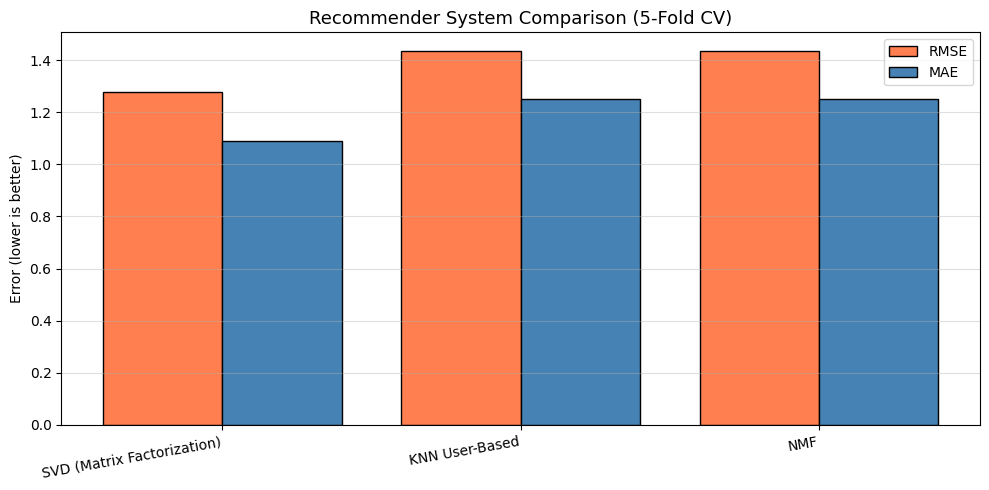

Saved: 10_recommender_comparison.png

Top 5 recommended professors (all departments):
         professor_name         dept  avg_rating  pct_positive  num_reviews
12        Angela  Mills      English         5.0         100.0            7
415        Shounak  Das      Biology         5.0         100.0            5
391   Ryan G  Vancleave      English         5.0         100.0            7
319  Morris  Longstreth      English         5.0         100.0            3
142             Fuller,  Mathematics         5.0         100.0            3


In [20]:
print("\n=== BUILDING RECOMMENDER SYSTEM ===")

# ── 9.1 Prepare data for Surprise ───────────────────────────────
# We'll recommend professors based on student star ratings
# Each (student_proxy, professor, rating) triplet
# Since we don't have real student IDs, we'll use row index as proxy

rec_df = df[['professor_name', 'student_star', 'dept_category']].copy()
rec_df = rec_df.dropna(subset=['student_star'])
rec_df['student_id'] = rec_df.index  # row index as student proxy

# Filter professors with at least 3 reviews
prof_counts = rec_df['professor_name'].value_counts()
rec_df = rec_df[rec_df['professor_name'].isin(prof_counts[prof_counts >= 3].index)]

print(f"Recommender data: {len(rec_df)} ratings, {rec_df['professor_name'].nunique()} professors")

# ── 9.2 Load into Surprise ──────────────────────────────────────
reader  = Reader(rating_scale=(1, 5))
data    = Dataset.load_from_df(rec_df[['student_id', 'professor_name', 'student_star']], reader)

# ── 9.3 Train 3 Recommender Models ──────────────────────────────
rec_models = {
    'SVD (Matrix Factorization)': SVD(n_factors=50, random_state=42),
    'KNN User-Based':             KNNBasic(sim_options={'user_based': True}),
    'NMF':                        NMF(n_factors=15, random_state=42)
}

print("\nEvaluating recommender models (5-fold CV)...")
rec_results = {}
for name, model in rec_models.items():
    cv_result = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    rmse = cv_result['test_rmse'].mean()
    mae  = cv_result['test_mae'].mean()
    rec_results[name] = {'RMSE': rmse, 'MAE': mae}
    print(f"  {name}: RMSE={rmse:.4f}, MAE={mae:.4f}")

# ── 9.4 Visualize recommender results ───────────────────────────
rec_names = list(rec_results.keys())
rmses = [rec_results[n]['RMSE'] for n in rec_names]
maes  = [rec_results[n]['MAE']  for n in rec_names]

x = np.arange(len(rec_names))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, rmses, 0.4, label='RMSE', color='coral',     edgecolor='black')
ax.bar(x + 0.2, maes,  0.4, label='MAE',  color='steelblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(rec_names, rotation=10, ha='right')
ax.set_title('Recommender System Comparison (5-Fold CV)', fontsize=13)
ax.set_ylabel('Error (lower is better)')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/10_recommender_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 10_recommender_comparison.png")

# ── 9.5 Build professor recommendation function ─────────────────
# Train best model on full data
trainset = data.build_full_trainset()
svd_model = SVD(n_factors=50, random_state=42)
svd_model.fit(trainset)

def recommend_professors(dept=None, top_n=5):
    """
    Recommend top-rated professors, optionally filtered by department.
    Based on average student ratings in the dataset.
    """
    prof_df = df.copy()
    if dept:
        prof_df = prof_df[prof_df['dept_category'].str.lower() == dept.lower()]

    summary = prof_df.groupby('professor_name').agg(
        avg_rating   = ('student_star', 'mean'),
        num_reviews  = ('student_star', 'count'),
        dept         = ('dept_category', 'first'),
        school       = ('school_name', 'first'),
        pct_positive = ('sentiment', lambda x: (x == 'positive').mean() * 100)
    ).reset_index()

    # Filter for professors with enough reviews
    summary = summary[summary['num_reviews'] >= 3]
    summary = summary.sort_values('avg_rating', ascending=False).head(top_n)
    return summary

print("\nTop 5 recommended professors (all departments):")
print(recommend_professors(top_n=5)[['professor_name','dept','avg_rating','pct_positive','num_reviews']].to_string())

#RAG Chatbot

In [22]:
print("\n=== BUILDING RAG CHATBOT ===")

# ── 10.1 Build retrieval index ───────────────────────────────────
# TF-IDF based similarity retrieval over all comments
tfidf_rag = TfidfVectorizer(
    stop_words='english',
    max_features=8000,
    ngram_range=(1, 2)
)
comment_matrix = tfidf_rag.fit_transform(df['clean_comments'])
print(f"RAG index built: {comment_matrix.shape[0]} documents, {comment_matrix.shape[1]} terms")

# ── 10.2 Retrieval function ──────────────────────────────────────
def retrieve_relevant_reviews(query, top_k=5, sentiment_filter=None,
                               dept_filter=None, aspect_filter=None):
    """
    Retrieve the most relevant reviews using TF-IDF cosine similarity.
    """
    query_clean = clean_text(query)
    query_vec   = tfidf_rag.transform([query_clean])
    similarities = cosine_similarity(query_vec, comment_matrix).flatten()

    # Get ranked indices
    ranked_idx = similarities.argsort()[::-1]

    # Apply filters
    filtered_df = df.copy()
    filtered_df['similarity'] = similarities

    if sentiment_filter:
        filtered_df = filtered_df[filtered_df['sentiment'] == sentiment_filter]
    if dept_filter:
        filtered_df = filtered_df[filtered_df['dept_category'].str.lower() == dept_filter.lower()]
    if aspect_filter:
        filtered_df = filtered_df[filtered_df['primary_aspect'] == aspect_filter]

    # Sort by similarity and return top_k
    top_reviews = filtered_df.nlargest(top_k, 'similarity')
    return top_reviews[['comments', 'sentiment', 'dept_category',
                         'primary_aspect', 'professor_name', 'similarity']]

# ── 10.3 Intent detection ───────────────────────────────────────
def detect_intent(query):
    """Detect what the user is asking about."""
    q = query.lower()

    intents = {
        'recommend':  any(w in q for w in ['recommend', 'best', 'top', 'suggest', 'good professor']),
        'negative':   any(w in q for w in ['complaint', 'bad', 'worst', 'negative', 'problem', 'issue']),
        'positive':   any(w in q for w in ['praise', 'great', 'positive', 'love', 'excellent']),
        'exams':      any(w in q for w in ['exam', 'test', 'quiz', 'midterm', 'final']),
        'grading':    any(w in q for w in ['grade', 'grading', 'mark', 'score']),
        'workload':   any(w in q for w in ['homework', 'workload', 'assignment', 'paper']),
        'lectures':   any(w in q for w in ['lecture', 'teaching', 'explain', 'class']),
        'summary':    any(w in q for w in ['summarize', 'summary', 'overview', 'common']),
        'department': any(w in q for w in ['english', 'math', 'psychology', 'biology', 'history']),
    }

    detected = [intent for intent, matched in intents.items() if matched]
    return detected if detected else ['general']

def detect_department(query):
    q = query.lower()
    for dept in ['english', 'mathematics', 'psychology', 'biology', 'history']:
        if dept.lower() in q or dept[:4].lower() in q:
            return dept
    return None

def detect_sentiment_filter(query):
    q = query.lower()
    if any(w in q for w in ['complaint', 'negative', 'bad', 'worst', 'problem']):
        return 'negative'
    if any(w in q for w in ['positive', 'great', 'praise', 'good']):
        return 'positive'
    return None

# ── 10.4 Response generator ─────────────────────────────────────
def summarize_reviews_text(reviews_df):
    """Extractive summarization of retrieved reviews."""
    total      = len(reviews_df)
    pos_pct    = (reviews_df['sentiment'] == 'positive').mean() * 100
    neg_pct    = (reviews_df['sentiment'] == 'negative').mean() * 100
    neu_pct    = (reviews_df['sentiment'] == 'neutral').mean() * 100
    top_aspect = reviews_df['primary_aspect'].value_counts().index[0] if len(reviews_df['primary_aspect'].value_counts()) > 0 else 'general'
    avg_rating = reviews_df['student_star'].mean() if 'student_star' in reviews_df.columns else None

    summary = f"Summary: Based on {total} reviews, {pos_pct:.0f}% positive, "
    summary += f"{neg_pct:.0f}% negative, {neu_pct:.0f}% neutral. "
    summary += f"Most discussed topic: {top_aspect.upper()}."
    if avg_rating and not np.isnan(avg_rating):
        summary += f" Avg rating: {avg_rating:.1f}/5."
    return summary


def generate_response(retrieved_reviews, query, intents):
    """Generate a structured response from retrieved reviews."""

    if retrieved_reviews.empty:
        return "I couldn't find any relevant reviews matching your query. Try rephrasing or asking about a specific department or topic."

    n = len(retrieved_reviews)
    sent_counts = retrieved_reviews['sentiment'].value_counts()

    # Build response
    response_parts = []

    # Header
    response_parts.append(f"Found {n} relevant student reviews.\n")

    # ── SUMMARIZATION (new) ──────────────────────────────────────
    response_parts.append(summarize_reviews_text(retrieved_reviews))
    response_parts.append("")  # blank line spacer

    # Sentiment summary
    if len(sent_counts) > 0:
        response_parts.append("Sentiment breakdown:")
        for sent, count in sent_counts.items():
            emoji = '✅' if sent == 'positive' else ('⚠️' if sent == 'neutral' else '❌')
            response_parts.append(f"   {emoji} {sent.capitalize()}: {count} review(s)")
        response_parts.append("")

    # Aspect summary
    aspect_counts = retrieved_reviews['primary_aspect'].value_counts()
    if len(aspect_counts) > 0:
        response_parts.append(f"Most discussed aspect: {aspect_counts.index[0].upper()}\n")

    # Sample reviews
    response_parts.append("Most relevant reviews:")
    for i, (_, row) in enumerate(retrieved_reviews.head(3).iterrows(), 1):
        sent_emoji = '✅' if row['sentiment'] == 'positive' else ('⚠️' if row['sentiment'] == 'neutral' else '❌')
        response_parts.append(f"\n{i}. [{sent_emoji} {row['sentiment'].upper()}] [{row['dept_category']}]")
        response_parts.append(f"   \"{row['comments'][:180]}{'...' if len(row['comments']) > 180 else ''}\"")

    # Recommendation if asked
    if 'recommend' in intents:
        dept = detect_department(query)
        recs = recommend_professors(dept=dept, top_n=3)
        if not recs.empty:
            response_parts.append("\n\nTop Recommended Professors:")
            for _, prof in recs.iterrows():
                response_parts.append(
                    f"   • {prof['professor_name']} ({prof['dept']}) "
                    f"— Rating: {prof['avg_rating']:.1f}/5 "
                    f"| {prof['pct_positive']:.0f}% positive reviews"
                )

    return '\n'.join(response_parts)

# ── 10.5 Main chatbot function ───────────────────────────────────
def chatbot(user_query, verbose=True):
    """
    Main RAG chatbot entry point.
    Takes a natural language query and returns a grounded answer.
    """
    if verbose:
        print(f"\n{'='*60}")
        print(f"USER: {user_query}")
        print('='*60)

    # Detect intent
    intents = detect_intent(user_query)
    dept    = detect_department(user_query)
    sent    = detect_sentiment_filter(user_query)

    if verbose:
        print(f"[Detected intents: {intents}]")
        print(f"[Department filter: {dept}]")
        print(f"[Sentiment filter: {sent}]")
        print()

    # Retrieve relevant reviews
    reviews = retrieve_relevant_reviews(
        query            = user_query,
        top_k            = 5,
        sentiment_filter = sent,
        dept_filter      = dept
    )

    # Generate and return response
    response = generate_response(reviews, user_query, intents)

    if verbose:
        print(response)

    return response

# ── 10.6 Test the chatbot ────────────────────────────────────────
print("\n\n" + "="*60)
print("CHATBOT DEMO TESTS")
print("="*60)

test_queries = [
    "What do students complain about exams?",
    "What are the best things about math professors?",
    "Can you recommend a good history professor?",
    "What do students say about grading in English?",
    "What are common complaints about workload?",
    "Which professors are most helpful outside class?"
]

for query in test_queries:
    chatbot(query)
    print()


=== BUILDING RAG CHATBOT ===
RAG index built: 4160 documents, 8000 terms


CHATBOT DEMO TESTS

USER: What do students complain about exams?
[Detected intents: ['exams']]
[Department filter: None]
[Sentiment filter: None]

Found 5 relevant student reviews.

Summary: Based on 5 reviews, 60% positive, 20% negative, 20% neutral. Most discussed topic: PROFESSOR.

Sentiment breakdown:
   ✅ Positive: 3 review(s)
   ❌ Negative: 1 review(s)
   ⚠️ Neutral: 1 review(s)

Most discussed aspect: PROFESSOR

Most relevant reviews:

1. [❌ NEGATIVE] [English]
   "Loved him in HU 221, but his modern lit class was the worst nightmare of my senior year. He was unclear in giving paper topics then would complain later and make you rewrite the pa..."

2. [⚠️ NEUTRAL] [Psychology]
   "how are her exams? what is the format of the class? how is her grading?"

3. [✅ POSITIVE] [Biology]
   "very helpful, I was not even supposed to be advised by him, just showed up for some help, and he was available. above and be

#Project Summary and Saving

In [23]:
df.to_csv('/content/rmp_final_with_features.csv', index=False)
print("Saved: rmp_final_with_features.csv")

# Summary JSON
summary = {
    "dataset": {
        "total_rows":        len(df),
        "departments":       df['dept_category'].nunique(),
        "unique_professors": df['professor_name'].nunique(),
        "sentiment_dist":    df['sentiment'].value_counts().to_dict()
    },
    "classification": {
        model: {
            "accuracy":    round(results[model]['accuracy'], 4),
            "f1_macro":    round(results[model]['f1_macro'], 4),
            "f1_weighted": round(results[model]['f1_weighted'], 4)
        }
        for model in results
    },
    "clustering": {
        "algorithm":        "KMeans",
        "n_clusters":       OPTIMAL_K,
        "silhouette_score": round(kmeans_sil, 4),
        "cluster_names":    cluster_name_map,
        "cluster_keywords": cluster_keywords
    },
    "recommender": {
        model: {
            "RMSE": round(rec_results[model]['RMSE'], 4),
            "MAE":  round(rec_results[model]['MAE'],  4)
        }
        for model in rec_results
    }
}

with open('/content/project_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("Saved: project_summary.json")
print(f"\nFiles saved:")
print("  /content/rmp_final_with_features.csv")
print("  /content/project_summary.json")
print("  /content/best_model_lr.joblib")
print("  /content/tfidf_vectorizer.joblib")
print("  /content/error_analysis_full.csv")
print("  /content/01_data_overview.png")
print("  /content/02_wordclouds.png")
print("  /content/03_tag_frequency.png")
print("  /content/04_model_comparison.png")
print("  /content/05_confusion_matrices.png")
print("  /content/06_error_analysis.png")
print("  /content/07_cluster_selection.png")
print("  /content/08_cluster_analysis.png")
print("  /content/09_tsne_clusters.png")
print("  /content/10_recommender_comparison.png")

Saved: rmp_final_with_features.csv
Saved: project_summary.json

Files saved:
  /content/rmp_final_with_features.csv
  /content/project_summary.json
  /content/best_model_lr.joblib
  /content/tfidf_vectorizer.joblib
  /content/error_analysis_full.csv
  /content/01_data_overview.png
  /content/02_wordclouds.png
  /content/03_tag_frequency.png
  /content/04_model_comparison.png
  /content/05_confusion_matrices.png
  /content/06_error_analysis.png
  /content/07_cluster_selection.png
  /content/08_cluster_analysis.png
  /content/09_tsne_clusters.png
  /content/10_recommender_comparison.png
